In [1]:
%autosave 60

Autosaving every 60 seconds




# Правила сдачи домашнего задания по ML competition 1 и ML competition 2:

1. Оценка проставляется тем студентам, кто побил baseline метрику (ваша метрика оказалась выше baseline на итоговом (!) leaderboard).

2. Помимо сабмита со скоромом выше baseline, студент должен прислать ipynb с финальным подходом к решению.

3. В этом ipynb:
должен быть сохранен output ячеек (не очищен (не применен clear output)).
Должно быть intro — описание вашего финального решения с такими пунктами:
как обработали данные;
какой алгоритм вы выбрали;
какие особенности использовали при его обучении;
как проводили валидацию алгоритма.
Должно быть outro — описание ваших вариантов по дальнейшему улучшению вашего итогового подхода с такими пунктами:
идея №1, которая может улучшить метрику, как ее реализовать (что для этого нужно сделать);
идея №2, которая может улучшить метрику, как ее реализовать (что для этого нужно сделать);
идея №3, которая может улучшить метрику, как ее реализовать (что для этого нужно сделать).

4. Ваш ник на Kaggle и скриншот с итоговой позицией на leaderboard (!важно — после завершения соревнования).
Написать в формате: ник ваш_ник, позиция 4.
(4 как пример итоговой позиции).
Вы побили baseline метрику: это 7 баллов.

Что проверяется в ноутбуке (за одно соревнование и проверку ноутбука максимум 10 баллов).

За что снижаются баллы:
- логичность и корректность intro / логичность и корректность outro;
- наличие / корректность валидации вашего алгоритма;
- корректность выбранной метрики.

Что может поднять балл:
- вы использовали особую loss-функцию;
- вы делали отбор и визуализировали важность данных;
- вы сделали свой кастомный ансамбль корректно;
- вы сделали визуализацию, которая мне понравилась.
## баллы
- За соревнование 1 можно получить максимум 10 баллов.
- За соревнование 1 можно получить дополнительные баллы.
- За соревнование 2 можно получить максимум 10 баллов.
- За соревнование 2 можно получить дополнительные баллы.

Общие правила получения дополнительных баллов:
- студенты, кто окажется в топ 5 на итоговом leaderboard в одном из соревнований, получат +4 балла;
- студенты, кто окажется в топ 5 на итоговом leaderboard в каждом соревновании, получат +8 баллов;
- любой, кто побил в каком-либо соревновании baseline метрику, может написать в общий чат (флудилку) свои мысли по следующему шаблону — получат +2 балла.
## Шаблон для +2 балла:
нужно написать схожий отчет для одного из соревнований (на ваш выбор), как intro / outro, с некоторыми дополнениями.

Структура:
- ваша итоговая позиция в выбранном соревновании;
- ваш intro;
- анализ того, что пробовали;
- анализ причин, что пошло не так (или что могло пойти не так, если всё было ок);
- анализ применимости вашего решения в бизнес-процессах: что и как применять, для чего, почему;
- ваш outro.
+ Тегнуть Арину, чтобы она добавила вам баллы.

# Feature Selection (Выбор признаков)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

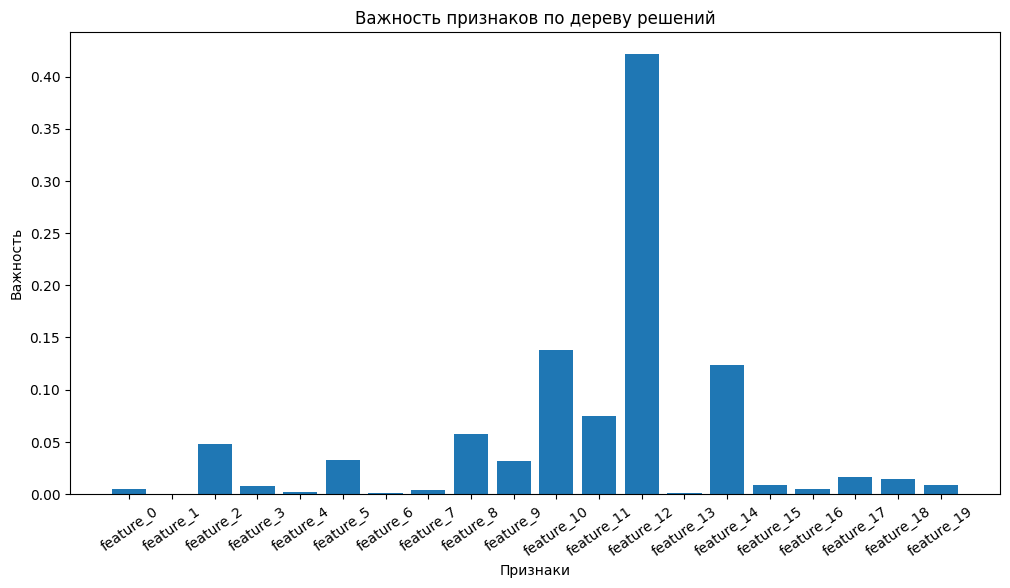

In [3]:
# Генерируем данные с избыточными признаками
X, y = make_classification(n_samples=1000, n_features=20, n_informative=5,
                          n_redundant=10, random_state=42)

# Создаем и обучаем дерево решений для оценки важности признаков
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X, y)
importance = dt.feature_importances_

# Визуализация важности признаков
plt.figure(figsize=(12, 6))
plt.bar(range(X.shape[1]), importance)
plt.xticks(range(X.shape[1]), [f'feature_{i}' for i in range(X.shape[1])], rotation=35)
plt.title('Важность признаков по дереву решений')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.show()

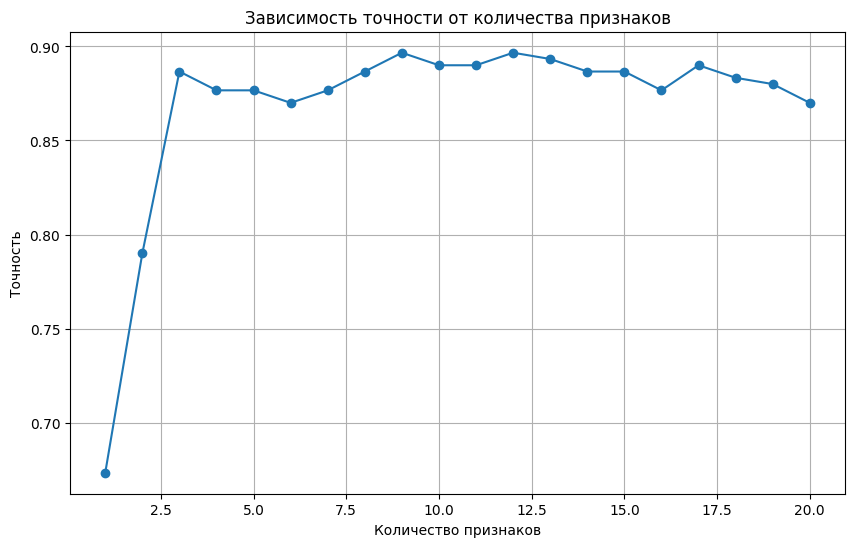

In [4]:
def evaluate_feature_count(X, y, max_features):
    results = []
    feature_indices = np.argsort(importance)[::-1]  # Сортировка по важности

    for n_features in range(1, max_features + 1):
        # Выбор n самых важных признаков
        selected_features = feature_indices[:n_features]
        X_selected = X[:, selected_features]

        # Разделение на обучающую и тестовую выборки
        X_train, X_test, y_train, y_test = train_test_split(
            X_selected, y, test_size=0.3, random_state=42)

        # Обучение модели
        model = DecisionTreeClassifier(random_state=42)
        model.fit(X_train, y_train)

        # Оценка на тестовой выборке
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results.append((n_features, accuracy))

    return results

results = evaluate_feature_count(X, y, 20)
features, accuracies = zip(*results)

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(features, accuracies, marker='o')
plt.xlabel('Количество признаков')
plt.ylabel('Точность')
plt.title('Зависимость точности от количества признаков')
plt.grid(True)
plt.show()


In [83]:
from copy import deepcopy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from tqdm import tqdm

In [86]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [87]:
path_files = 'drive/MyDrive/ШАД 2025/'
train = pd.read_csv(path_files + 'train_2.csv')

In [88]:
train.drop('_id', axis=1, inplace=True)

In [89]:
train.drop('last_dt', axis=1, inplace=True)

In [90]:
train.head()

,name,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,avg_reviews,total_host,target
0,Belle Harbor 4 BR 2 bath- 1 bl from Beach,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,350,2,5,2.88,1,334
1,"Come see Brooklyn, New York",Howard T.,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,40,5,8,0.13,1,0
2,Large 2Br on W71st & Columbus Feb 19-28,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,NaN,1,0
3,Perfect bedroom. Near Subways Columbia CityCol...,Federico,Manhattan,Harlem,40.81530,-73.95080,Private room,65,2,18,0.64,1,0
4,Cozy Sun Filled Fresh Guest Room in Artsy Bush...,Lisa,Brooklyn,Bushwick,40.70230,-73.92935,Private room,99,2,26,0.76,1,155


In [91]:
train.drop(['name', 'host_name'], axis=1, inplace=True)

In [97]:
cat_columns = [
    'location_cluster', 'type_house',
]

In [98]:
train.drop(['location'], axis=1, inplace=True)

In [99]:
target = deepcopy((train['target'] > train['target'].median()).values.astype(int))

In [100]:
train.drop('target', axis=1, inplace=True)

In [101]:
train, test, target, y_test = train_test_split(train, target, test_size=0.33, random_state=42)

In [102]:
ohe = OneHotEncoder(drop='first', sparse_output=False, )
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', ohe, cat_columns)
])

In [103]:
train = preprocessor.fit_transform(train)
test = preprocessor.fit_transform(test)

## backward selection

In [104]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [105]:
from sklearn import set_config
set_config(transform_output="pandas")

In [110]:
def backward_selection(X, y, tol=0.01):
    """
    Реализация алгоритма обратного исключения (backward selection)

    Алгоритм начинает со всеми признаками и последовательно удаляет наименее значимые,
    пока качество модели не перестанет улучшаться.
    """
    # Создаем копию данных
    X_copy = X.copy()

    # Разделяем данные на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X_copy, y, test_size=0.3, random_state=42)

    # Создаем модель
    model = DecisionTreeClassifier(random_state=42)

    # Обучаем модель на всех признаках
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    best_score = accuracy_score(y_test, y_pred)

    print(f"Начальная точность (все признаки): {best_score:.4f}")

    # Список всех признаков
    all_features = list(X_train.columns)
    best_features = all_features.copy()

    # Итеративно удаляем признаки
    while len(all_features) > 1:
        temp_score = []
        temp_features = []

        # Проверяем каждый признак
        for feature in all_features:
            # Создаем набор данных без текущего признака
            temp_X_train = X_train.drop(feature, axis=1)
            temp_X_test = X_test.drop(feature, axis=1)

            # Создаем новую модель
            temp_model = DecisionTreeClassifier(random_state=42)

            # Обучаем модель
            temp_model.fit(temp_X_train, y_train)
            temp_y_pred = temp_model.predict(temp_X_test)
            temp_score.append(accuracy_score(y_test, temp_y_pred))
            temp_features.append(feature)

        # Находим признак, удаление которого дает наилучший результат
        max_score_idx = np.argmax(temp_score)

        # Если удаление признака улучшает или не ухудшает модель
        if temp_score[max_score_idx] >= best_score - tol:
            # Обновляем лучший результат
            best_score = temp_score[max_score_idx]
            # Удаляем признак из списка
            feature_to_remove = temp_features[max_score_idx]
            all_features.remove(feature_to_remove)
            best_features.remove(feature_to_remove)
            print(f"Удален признак: {feature_to_remove}, новая точность: {best_score:.4f}")
        else:
            # Если удаление любого признака ухудшает модель, останавливаемся
            break

    print(f"Лучший набор признаков: {best_features}")
    print(f"Лучшая точность: {best_score:.4f}")

    return best_features

In [112]:
train.shape

(24569, 6)

In [113]:
best_features = backward_selection(train, target)

Начальная точность (все признаки): 0.5476
Удален признак: cat__location_cluster_Staten Island, новая точность: 0.5480
Удален признак: cat__location_cluster_Queens, новая точность: 0.5476
Удален признак: cat__type_house_Private room, новая точность: 0.5476
Удален признак: cat__type_house_Shared room, новая точность: 0.5439
Удален признак: cat__location_cluster_Brooklyn, новая точность: 0.5409
Лучший набор признаков: ['cat__location_cluster_Manhattan']
Лучшая точность: 0.5409


## forward selection

In [114]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def forward_selection(X, y):
    """
    Реализация алгоритма прямого отбора (forward selection)

    Алгоритм начинает с пустого набора признаков и последовательно добавляет
    наиболее значимые, пока качество модели не перестанет улучшаться.
    """
    # Создаем копию данных
    X_copy = X.copy()

    # Разделяем данные на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X_copy, y, test_size=0.3, random_state=42)

    # Список всех признаков
    all_features = list(X_train.columns)
    # Список выбранных признаков (изначально пустой)
    selected_features = []

    # Лучшая точность (изначально 0)
    best_score = 0

    # Продолжаем добавлять признаки, пока не перестанет улучшаться точность
    while len(selected_features) < len(all_features):
        temp_score = []
        temp_features = []

        # Проверяем каждый признак, который еще не выбран
        for feature in [f for f in all_features if f not in selected_features]:
            # Создаем временный список признаков, включая текущий
            temp_selected = selected_features + [feature]

            # Выбираем только нужные столбцы из данных
            temp_X_train = X_train[temp_selected]
            temp_X_test = X_test[temp_selected]

            # Создаем новую модель
            temp_model = DecisionTreeClassifier(random_state=42)

            # Обучаем модель
            temp_model.fit(temp_X_train, y_train)
            temp_y_pred = temp_model.predict(temp_X_test)
            temp_score.append(accuracy_score(y_test, temp_y_pred))
            temp_features.append(feature)

        # Находим признак, добавление которого дает наилучший результат
        max_score_idx = np.argmax(temp_score)

        # Если добавление признака улучшает модель
        if temp_score[max_score_idx] > best_score:
            # Обновляем лучший результат
            best_score = temp_score[max_score_idx]
            # Добавляем признак в список выбранных
            feature_to_add = temp_features[max_score_idx]
            selected_features.append(feature_to_add)
            print(f"Добавлен признак: {feature_to_add}, новая точность: {best_score:.4f}")
        else:
            # Если добавление любого признака не улучшает модель, останавливаемся
            break

    print(f"Лучший набор признаков: {selected_features}")
    print(f"Лучшая точность: {best_score:.4f}")

    return selected_features

In [115]:
best_features = forward_selection(train, target)

Добавлен признак: cat__location_cluster_Queens, новая точность: 0.5340
Добавлен признак: cat__type_house_Shared room, новая точность: 0.5387
Добавлен признак: cat__location_cluster_Staten Island, новая точность: 0.5409
Лучший набор признаков: ['cat__location_cluster_Queens', 'cat__type_house_Shared room', 'cat__location_cluster_Staten Island']
Лучшая точность: 0.5409


## permutation importance

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

def permutation_importance(X, y, n_repeats=10, threshold=0.01, metric='accuracy', n_top_features=None, plot=True):
    """
    Реализация алгоритма важности на основе перестановок (permutation importance)

    Алгоритм оценивает важность признака путем перемешивания его значений и
    измерения ухудшения производительности модели.

    Параметры:
    ----------
    X : pandas DataFrame
        Датафрейм с признаками
    y : pandas Series или numpy array
        Целевая переменная
    n_repeats : int, по умолчанию 10
        Количество повторений перемешивания для каждого признака
    threshold : float, по умолчанию 0.01
        Пороговое значение важности для отбора признаков
    metric : str, по умолчанию 'accuracy'
        Метрика для оценки качества модели ('accuracy' или 'roc_auc')
    n_top_features : int или None, по умолчанию None
        Количество лучших признаков для отбора. Если указано, threshold игнорируется
    plot : bool, по умолчанию True
        Создавать ли график важности признаков

    Возвращает:
    -----------
    pandas DataFrame
        Датафрейм с важностью признаков и обоснованием выбора
    list
        Список выбранных признаков
    """
    # Проверка корректности параметров
    if metric not in ['accuracy', 'roc_auc']:
        raise ValueError("Метрика должна быть 'accuracy' или 'roc_auc'")

    # Создаем копию данных
    X_copy = X.copy()

    # Разделяем данные на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X_copy, y, test_size=0.3, random_state=42)

    # Создаем модель
    model = DecisionTreeClassifier(random_state=42)

    # Обучаем модель на всех признаках
    model.fit(X_train, y_train)

    # Предсказания на тестовой выборке
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if metric == 'roc_auc' else None

    # Вычисляем базовую метрику
    if metric == 'accuracy':
        baseline_score = accuracy_score(y_test, y_pred)
    else:  # roc_auc
        baseline_score = roc_auc_score(y_test, y_pred_proba)

    print(f"Базовая {metric} модели: {baseline_score:.4f}")

    # Словарь для хранения важности признаков
    feature_importance = {}
    feature_scores = {}

    # Для каждого признака
    for feature in X_test.columns:
        importance_scores = []
        permuted_scores = []
        #

        # Повторяем n_repeats раз для получения стабильных результатов
        for _ in range(n_repeats):
            # Создаем копию тестовых данных
            X_test_permuted = X_test.copy()

            # Перемешиваем значения текущего признака
            X_test_permuted[feature] = np.random.permutation(X_test_permuted[feature].values)

            # Делаем предсказания с перемешанным признаком
            y_pred_permuted = model.predict(X_test_permuted)

            # Вычисляем новую метрику
            if metric == 'accuracy':
                permuted_score = accuracy_score(y_test, y_pred_permuted)
            else:  # roc_auc
                y_pred_proba_permuted = model.predict_proba(X_test_permuted)[:, 1]
                permuted_score = roc_auc_score(y_test, y_pred_proba_permuted)

            permuted_scores.append(permuted_score)

            # Важность признака - это снижение метрики
            importance = baseline_score - permuted_score
            importance_scores.append(importance)

        # Средняя важность признака по всем повторениям
        feature_importance[feature] = np.mean(importance_scores)
        # Сохраняем также средний score после перемешивания
        feature_scores[feature] = np.mean(permuted_scores)

    # Создаем DataFrame с результатами
    importance_df = pd.DataFrame({
        'feature': list(feature_importance.keys()),
        'importance': list(feature_importance.values()),
        'permuted_score': list(feature_scores.values())
    }).sort_values('importance', ascending=False)

    # Добавляем процент снижения метрики
    importance_df['percent_decrease'] = (importance_df['importance'] / baseline_score) * 100

    # Добавляем обоснование выбора
    def get_justification(row):
        if row['importance'] <= 0:
            return "Признак не влияет на качество модели или его перемешивание улучшает модель"
        elif row['percent_decrease'] < 1:
            return "Незначительное влияние на модель (менее 1% снижения метрики)"
        elif row['percent_decrease'] < 5:
            return "Умеренное влияние на модель (1-5% снижения метрики)"
        elif row['percent_decrease'] < 10:
            return "Существенное влияние на модель (5-10% снижения метрики)"
        else:
            return "Критически важный признак (более 10% снижения метрики)"

    importance_df['justification'] = importance_df.apply(get_justification, axis=1)

    # Определяем, какие признаки выбрать
    if n_top_features is not None:
        # Выбираем top-N признаков
        selected_features = importance_df.head(n_top_features)['feature'].tolist()
        importance_df['selected'] = importance_df['feature'].isin(selected_features)
    else:
        # Выбираем признаки с важностью выше порогового значения
        selected_features = importance_df[importance_df['importance'] > threshold]['feature'].tolist()
        importance_df['selected'] = importance_df['importance'] > threshold

    # Выводим результаты
    print("\nВажность признаков (permutation importance):")
    print(importance_df)

    print(f"\nВыбрано {len(selected_features)} признаков:")
    for feature in selected_features:
        row = importance_df[importance_df['feature'] == feature].iloc[0]
        print(f"- {feature}: важность = {row['importance']:.4f}, "
              f"снижение метрики = {row['percent_decrease']:.2f}%, "
              f"обоснование: {row['justification']}")

    # Визуализация важности признаков
    if plot and not importance_df.empty:
        plt.figure(figsize=(12, 8))

        # Создаем цветовую схему: выбранные признаки - зеленые, остальные - серые
        colors = ['green' if selected else 'gray' for selected in importance_df['selected']]

        # Сортируем признаки по важности
        sorted_df = importance_df.sort_values('importance')

        # Создаем горизонтальный bar plot
        plt.barh(sorted_df['feature'], sorted_df['importance'], color=colors)

        # Добавляем вертикальную линию для порогового значения
        if n_top_features is None:
            plt.axvline(x=threshold, color='red', linestyle='--',
                        label=f'Пороговое значение ({threshold})')
            plt.legend()

        plt.xlabel('Важность (снижение метрики)')
        plt.ylabel('Признаки')
        plt.title('Permutation Importance признаков')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()

        # Сохраняем график
        plt.show("permutation_importance.png")
        print("График важности признаков сохранен как 'permutation_importance.png'")

    return importance_df, selected_features

Базовая accuracy модели: 0.5476

Важность признаков (permutation importance):
                               feature  importance  permuted_score  \
0       cat__location_cluster_Brooklyn    0.023850        0.523701   
1      cat__location_cluster_Manhattan    0.010514        0.537037   
5          cat__type_house_Shared room    0.005454        0.542097   
2         cat__location_cluster_Queens    0.003934        0.543617   
3  cat__location_cluster_Staten Island    0.000298        0.547253   
4         cat__type_house_Private room    0.000000        0.547551   

   percent_decrease                                      justification  \
0          4.355798  Умеренное влияние на модель (1-5% снижения мет...   
1          1.920218  Умеренное влияние на модель (1-5% снижения мет...   
5          0.996036  Незначительное влияние на модель (менее 1% сни...   
2          0.718533  Незначительное влияние на модель (менее 1% сни...   
3          0.054509  Незначительное влияние на модель (менее 

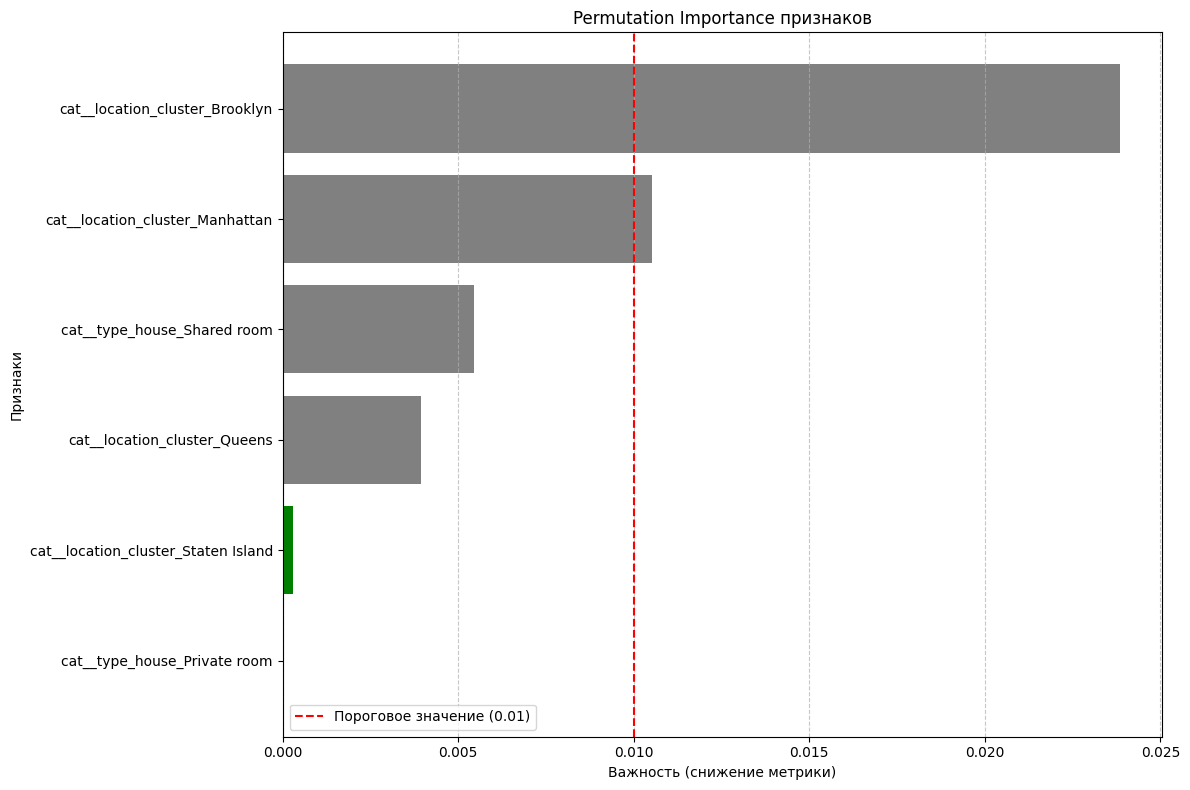

График важности признаков сохранен как 'permutation_importance.png'


In [121]:
importance_df, selected_features = permutation_importance(
    train, target, n_repeats=10, threshold=0.01, metric='accuracy'
)

In [ ]:
# eli5

# Random Forest

In [47]:
# Функция для генерации бутстреп-выборки
def bootstrap_sample(X, y):
    n_samples = X.shape[0]
    idxs = np.random.choice(n_samples, n_samples, replace=True)
    return X[idxs], y[idxs]

# Класс для узла дерева решений
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

# Функция для расчета энтропии
def calculate_entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
    return entropy

# Функция для расчета информационного прироста
def information_gain(y, X_column, threshold):
    # Расчет энтропии до сплита
    parent_entropy = calculate_entropy(y)

    # Создание дочерних наборов
    left_idxs = np.argwhere(X_column <= threshold).flatten()
    right_idxs = np.argwhere(X_column > threshold).flatten()

    # Если не удаётся разделить, возвращаем 0
    if len(left_idxs) == 0 or len(right_idxs) == 0:
        return 0

    # Расчет энтропии после сплита
    n = len(y)
    n_l, n_r = len(left_idxs), len(right_idxs)
    e_l = calculate_entropy(y[left_idxs])
    e_r = calculate_entropy(y[right_idxs])
    child_entropy = (n_l / n) * e_l + (n_r / n) * e_r

    # Расчет информационного прироста
    information_gain = parent_entropy - child_entropy
    return information_gain

# Функция для поиска лучшего сплита
def find_best_split(X, y, feat_idxs):
    best_gain = -1
    split_idx, split_threshold = None, None

    for feat_idx in feat_idxs:
        X_column = X[:, feat_idx]
        thresholds = np.unique(X_column)

        for threshold in thresholds:
            gain = information_gain(y, X_column, threshold)

            if gain > best_gain:
                best_gain = gain
                split_idx = feat_idx
                split_threshold = threshold

    return split_idx, split_threshold, best_gain


# Класс для дерева решений
class DecisionTreeFromScratch:
    def __init__(self, max_depth=10, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_class_labels = len(np.unique(y))

        # Критерии остановки
        if (depth >= self.max_depth or n_class_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Случайный выбор признаков
        max_feats = self.max_features if self.max_features else n_features
        feat_idxs = np.random.choice(n_features, max_feats, replace=False)

        # Поиск лучшего сплита
        best_feature, best_threshold, _ = find_best_split(X, y, feat_idxs)

        # Создание дочерних узлов
        left_idxs = np.argwhere(X[:, best_feature] <= best_threshold).flatten()
        right_idxs = np.argwhere(X[:, best_feature] > best_threshold).flatten()

        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)

        return Node(best_feature, best_threshold, left, right)

    def _most_common_label(self, y):
        counter = {}
        for label in y:
            if label in counter:
                counter[label] += 1
            else:
                counter[label] = 1
        return max(counter, key=counter.get)

    def fit(self, X, y):
        self.root = self._grow_tree(X, y)

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

    def predict(self, X):
        predictions = [self._traverse_tree(x, self.root) for x in X]
        return np.array(predictions)

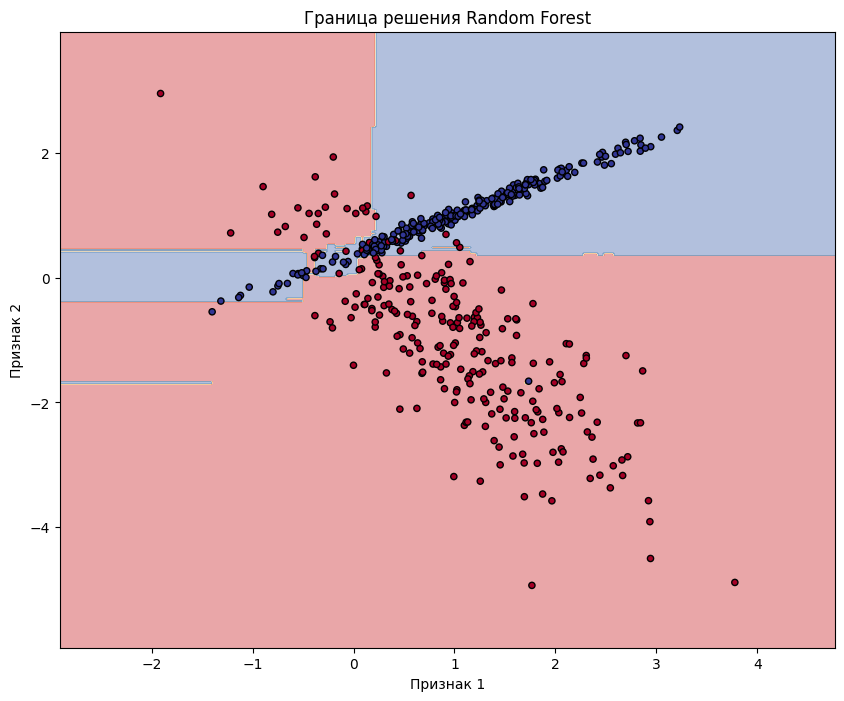

In [48]:
# Класс для Random Forest
class RandomForestFromScratch:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2, max_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []

        for _ in range(self.n_trees):
            tree = DecisionTreeFromScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )

            # Бутстреп-выборка
            X_sample, y_sample = bootstrap_sample(X, y)

            # Обучение дерева
            tree.fit(X_sample, y_sample)

            # Добавление дерева в лес
            self.trees.append(tree)

    def predict(self, X):
        # Получение предсказаний от каждого дерева
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])

        # Голосование (для классификации)
        predictions = []
        for sample_idx in range(X.shape[0]):
            sample_predictions = tree_predictions[:, sample_idx]
            # Нахождение наиболее частого класса
            counter = {}
            for pred in sample_predictions:
                if pred in counter:
                    counter[pred] += 1
                else:
                    counter[pred] = 1
            most_common = max(counter, key=counter.get)
            predictions.append(most_common)

        return np.array(predictions)

# Визуализация границы решения
def plot_decision_boundary(X, y, model, title="Граница решения"):
    # Создаем сетку для визуализации
    h = 0.02  # Шаг сетки
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Предсказание для каждой точки сетки
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Построение границы решения
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
    plt.title(title)
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.show()

# Пример использования Random Forest
from sklearn.datasets import make_classification

# Генерация 2D-данных для визуализации
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                         n_informative=2, random_state=42, n_clusters_per_class=1)

# Обучение Random Forest на данных
forest = RandomForestFromScratch(n_trees=10, max_depth=5, max_features=1)
forest.fit(X, y)

# Визуализация границы решения
plot_decision_boundary(X, y, forest, "Граница решения Random Forest")

# Bias-Variance Trade-off

In [49]:
import os

In [129]:
from google.colab import drive
drive.mount('/content/drive/')

path_files = 'drive/MyDrive/ШАД 2025/'
train = pd.read_csv(path_files + 'train_2.csv')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [130]:
train.shape

(36671, 15)

In [131]:
y = (train['target'] > train['target'].median()).values

In [132]:
X = train[['lat', 'lon']].values

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
from matplotlib.colors import ListedColormap

np.random.seed(42)

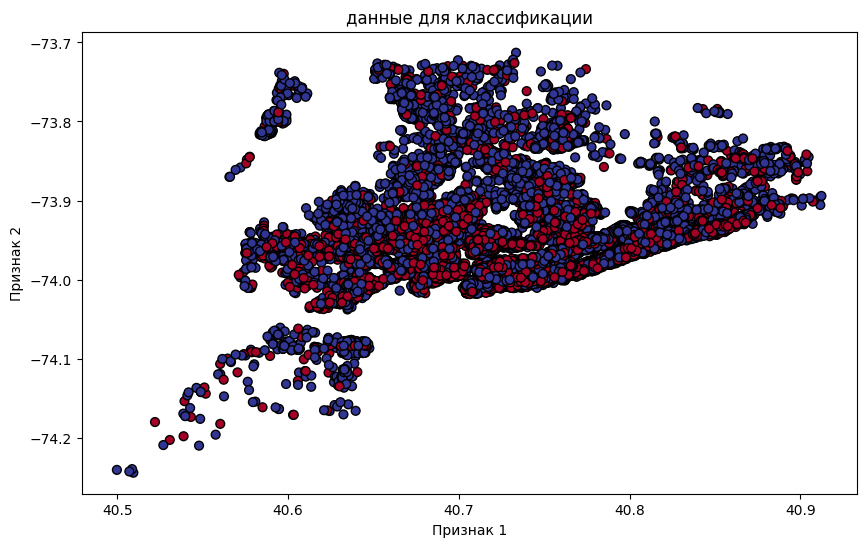

<ipython-input-56-193096ad08e8>:68: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=20, edgecolor='k', cmap=plt.cm.RdYlBu, marker='x', label='Тестовые данные')
<ipython-input-56-193096ad08e8>:68: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=20, edgecolor='k', cmap=plt.cm.RdYlBu, marker='x', label='Тестовые данные')
<ipython-input-56-193096ad08e8>:68: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=20, edgecol

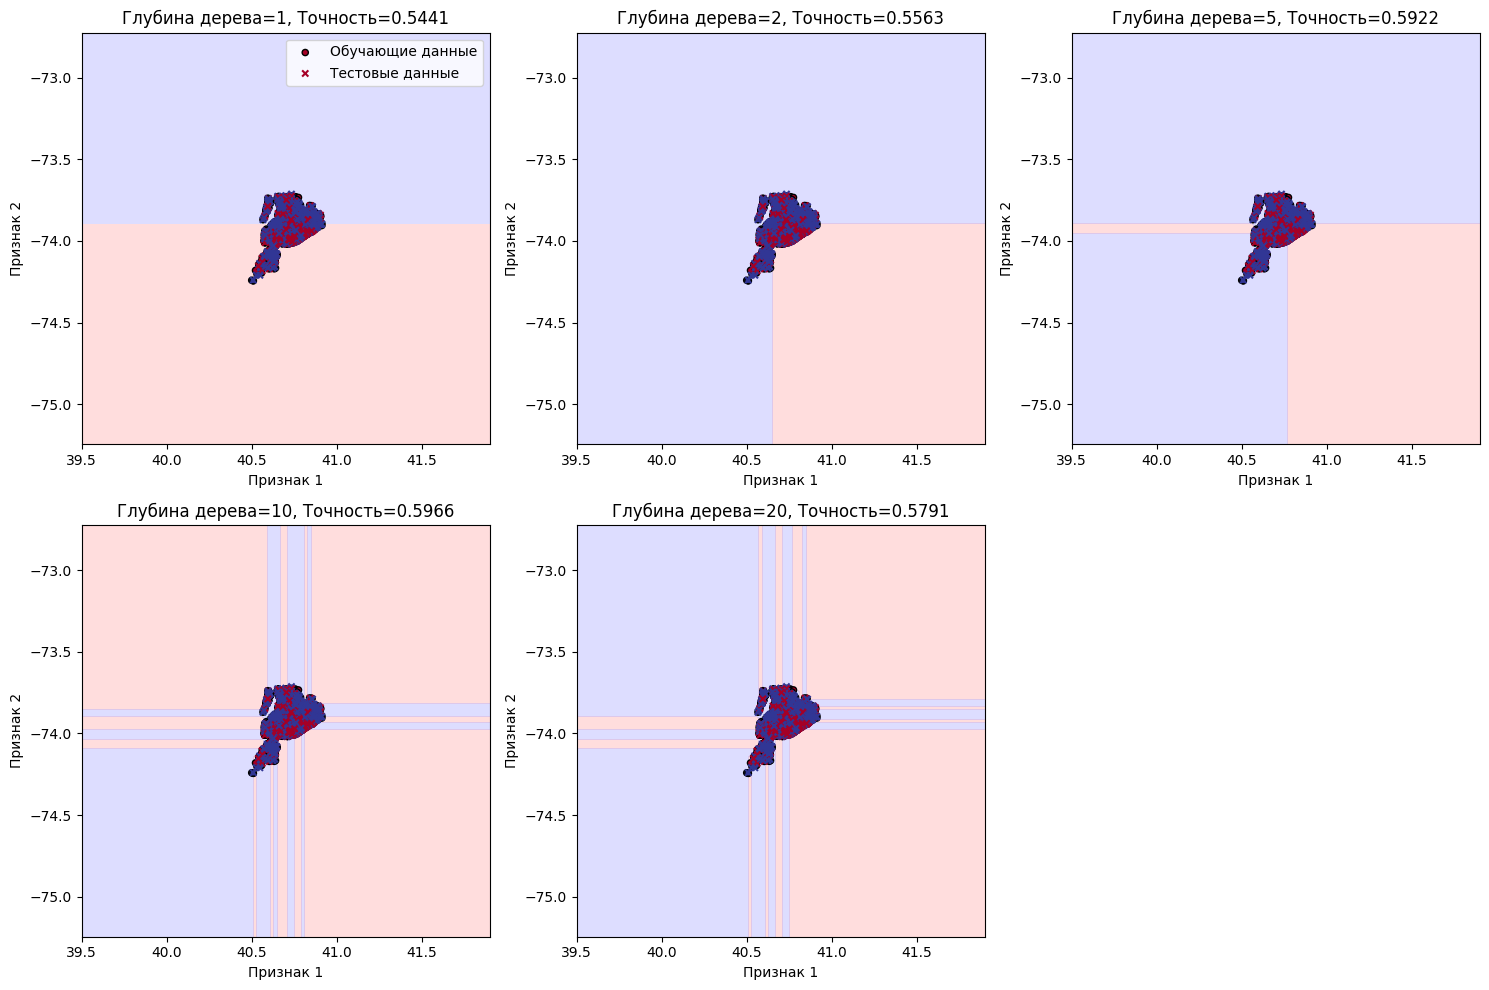

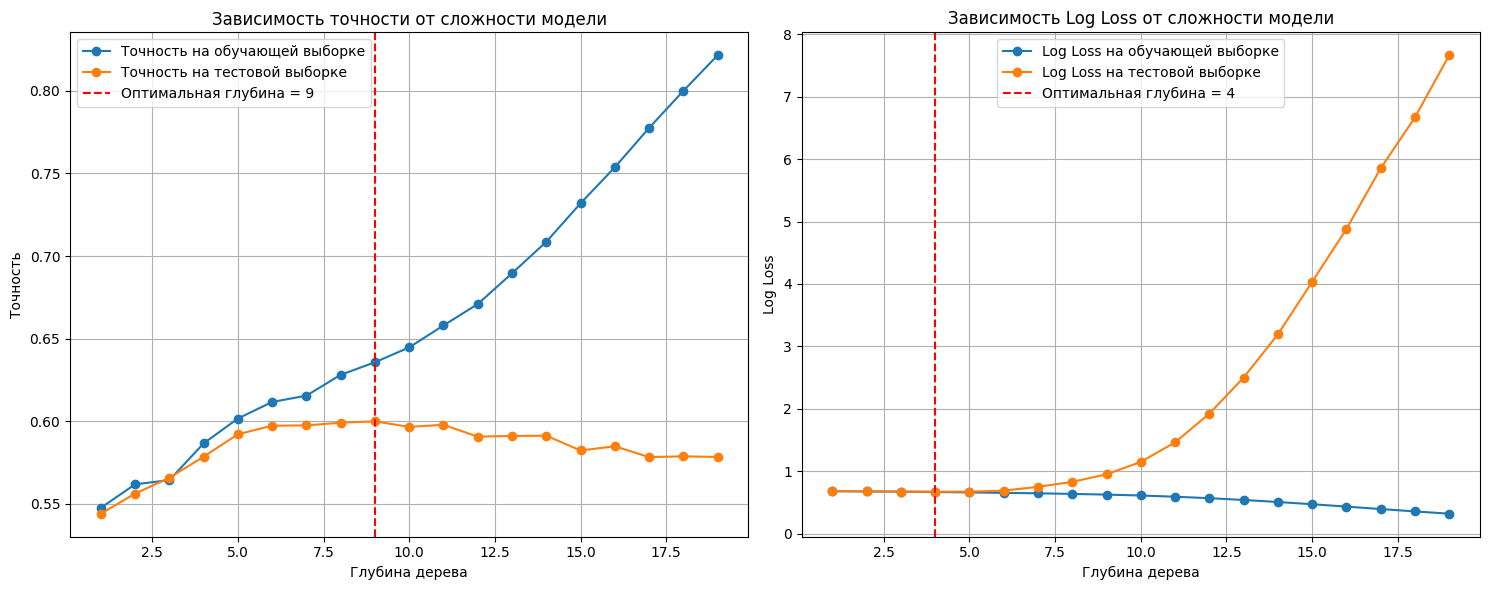

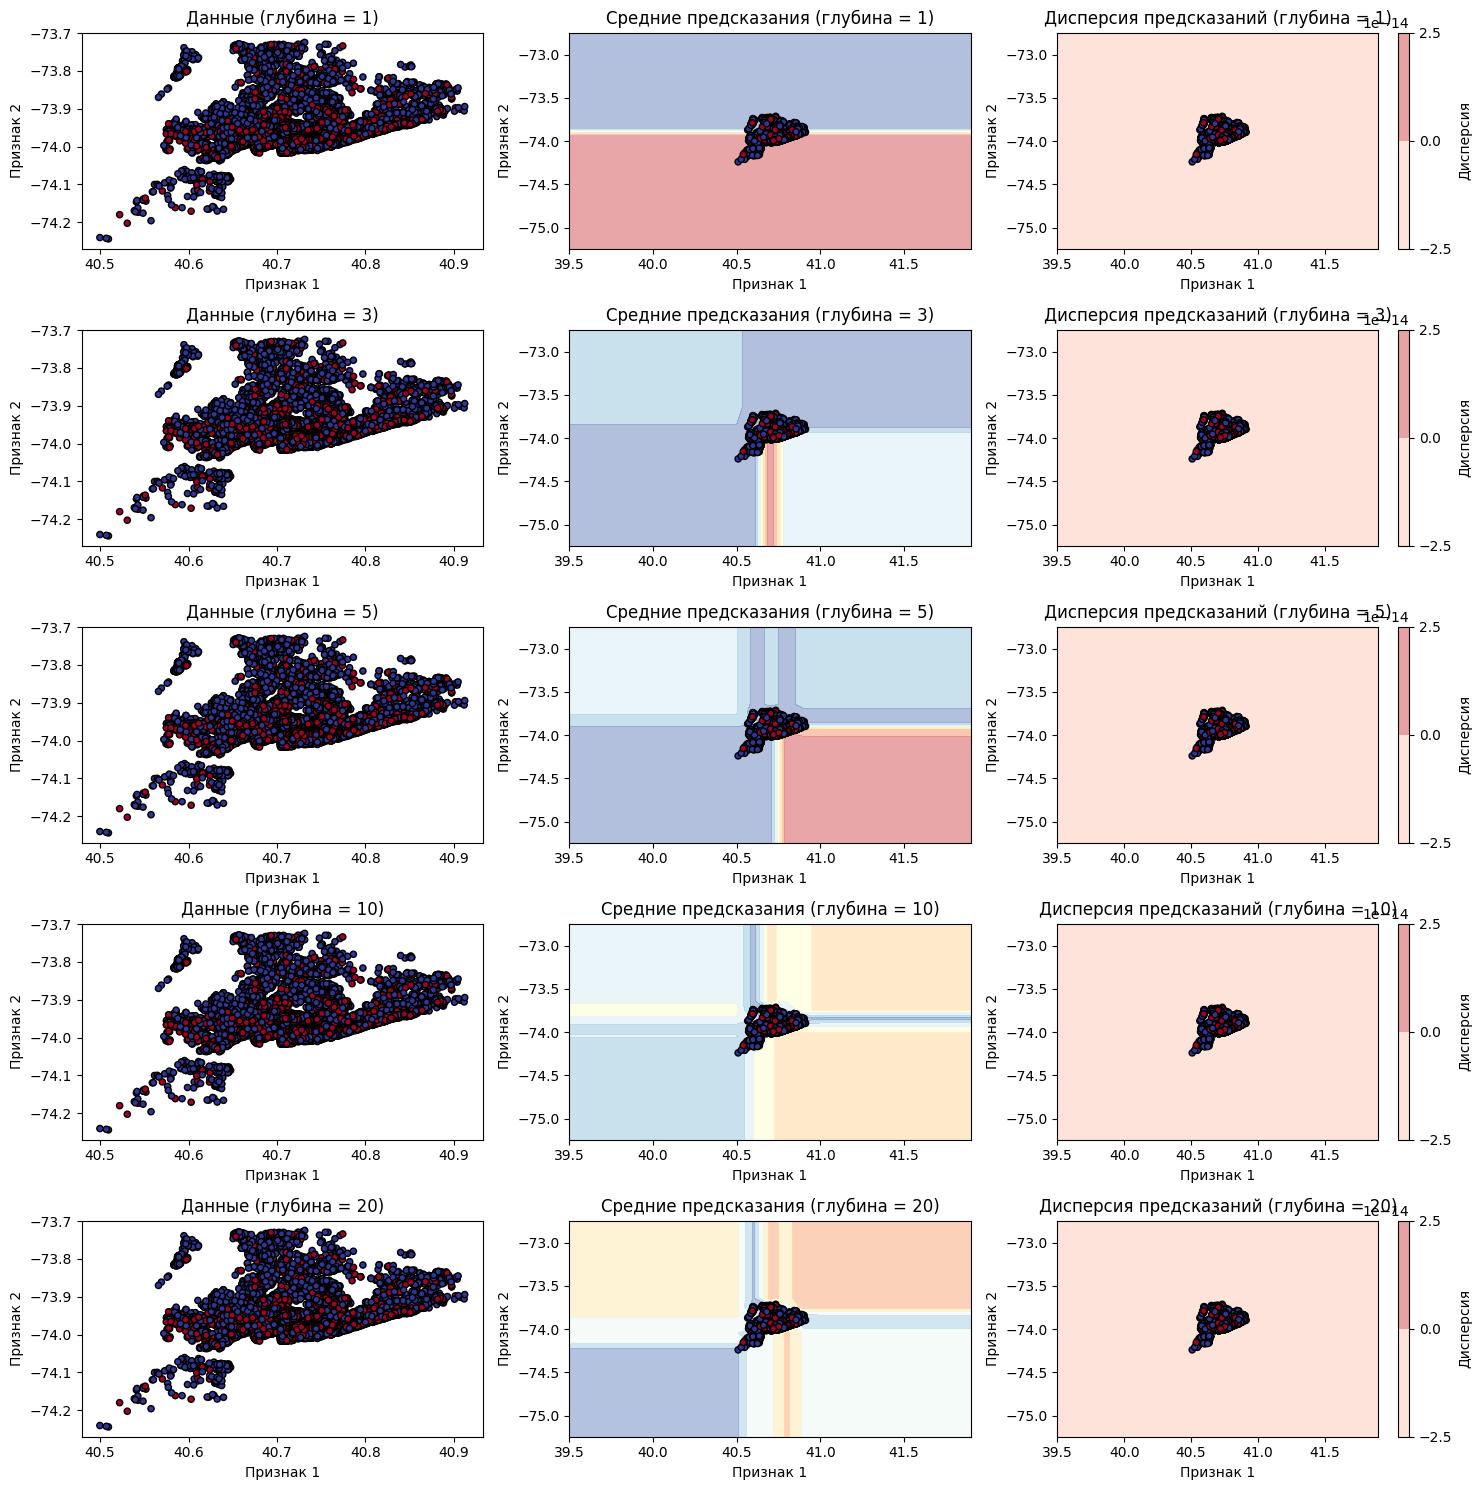

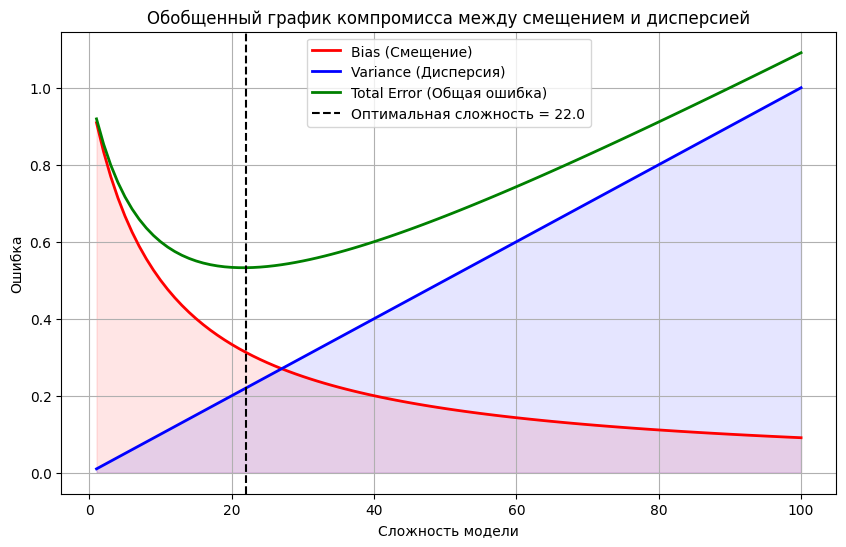

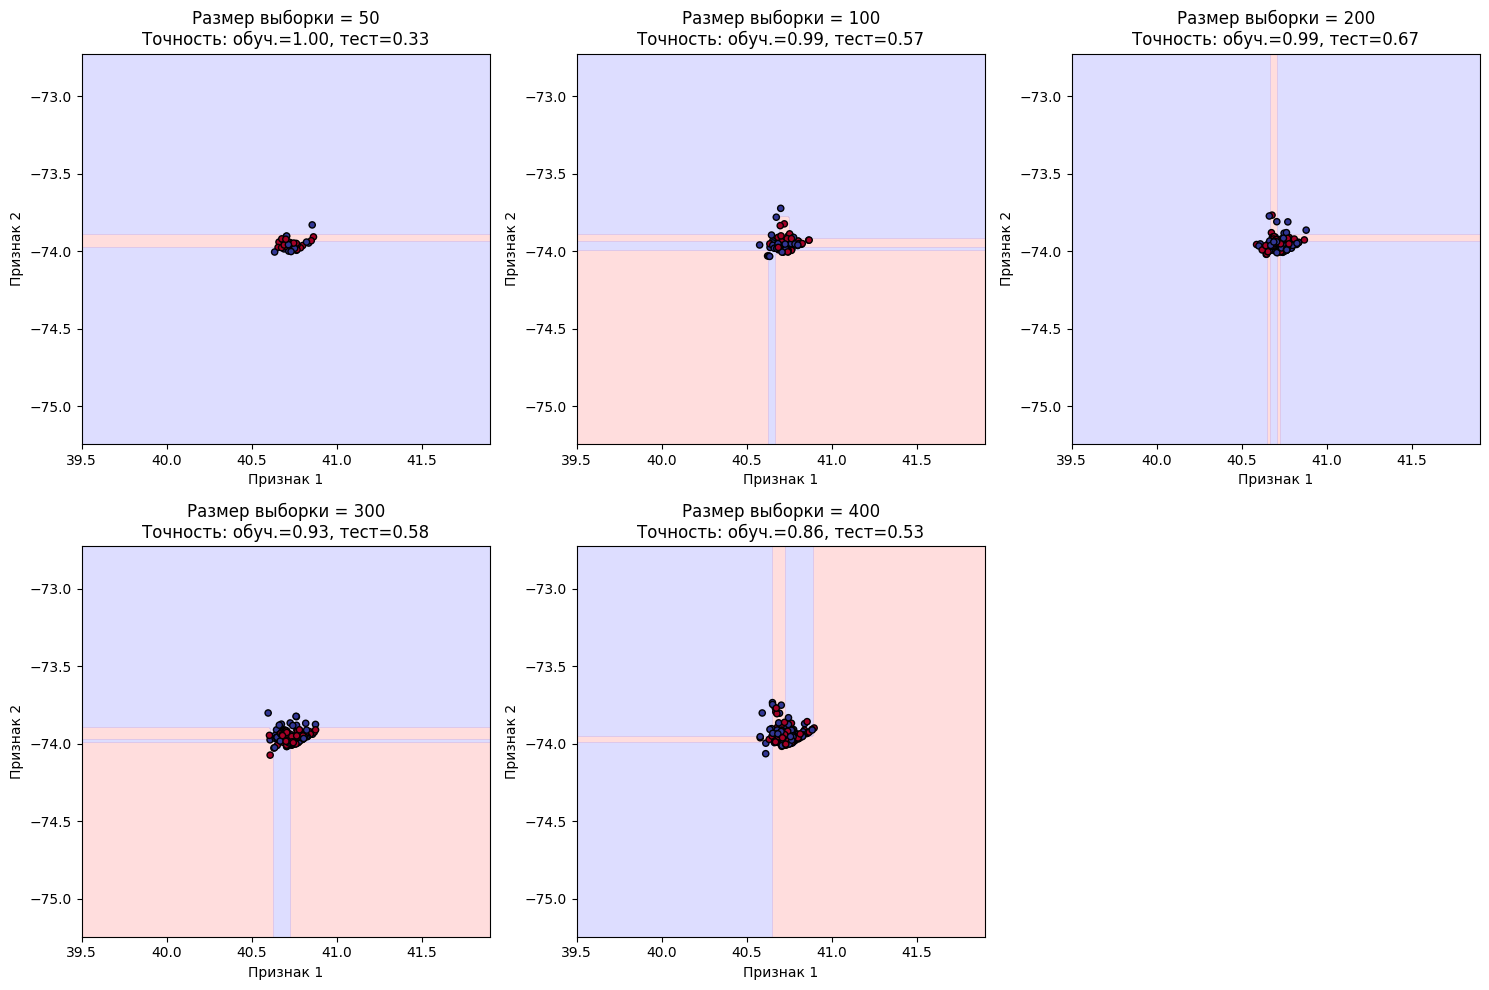

In [56]:
# Визуализация данных
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k', s=40)
plt.title('данные для классификации')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.show()

# Функция для визуализации границы решения
def plot_decision_boundary(X, y, model, title="Граница решения"):
    # Создаем сетку для визуализации
    h = 0.02  # Шаг сетки
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Предсказание для каждой точки сетки
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Построение границы решения
    cm = ListedColormap(['#FFAAAA', '#AAAAFF'])
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=cm)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
    plt.title(title)
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.show()

# Функция для обучения модели с разной глубиной и визуализации
def plot_tree_complexity(X, y, max_depths=[1, 2, 5, 10, 20]):
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    plt.figure(figsize=(15, 10))

    for i, max_depth in enumerate(max_depths):
        # Обучение дерева с заданной глубиной
        tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
        tree.fit(X_train, y_train)

        # Предсказание
        y_pred = tree.predict(X_test)

        # Расчет точности
        accuracy = accuracy_score(y_test, y_pred)

        # Визуализация границы решения
        plt.subplot(2, 3, i+1)

        # Создаем сетку для визуализации
        h = 0.02  # Шаг сетки
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))

        # Предсказание для каждой точки сетки
        Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Построение границы решения
        cm = ListedColormap(['#FFAAAA', '#AAAAFF'])
        plt.contourf(xx, yy, Z, alpha=0.4, cmap=cm)
        plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, edgecolor='k', cmap=plt.cm.RdYlBu, marker='o', label='Обучающие данные')
        plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=20, edgecolor='k', cmap=plt.cm.RdYlBu, marker='x', label='Тестовые данные')
        plt.title(f'Глубина дерева={max_depth}, Точность={accuracy:.4f}')
        plt.xlabel('Признак 1')
        plt.ylabel('Признак 2')

        if i == 0:
            plt.legend()

    plt.tight_layout()
    plt.show()

# Визуализация bias-variance trade-off
plot_tree_complexity(X, y, max_depths=[1, 2, 5, 10, 20])

# Визуализация зависимости ошибки от сложности модели
def plot_bias_variance_tradeoff(X, y):
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    max_depths = range(1, 20)
    train_accuracies = []
    test_accuracies = []
    train_losses = []
    test_losses = []

    for depth in max_depths:
        # Обучение дерева
        tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
        tree.fit(X_train, y_train)

        # Предсказания и метрики
        y_train_pred = tree.predict(X_train)
        y_test_pred = tree.predict(X_test)

        # Вероятности для расчета log_loss
        y_train_proba = tree.predict_proba(X_train)
        y_test_proba = tree.predict_proba(X_test)

        # Точность
        train_accuracy = accuracy_score(y_train, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)

        # Log loss (для более плавной кривой ошибки)
        train_loss = log_loss(y_train, y_train_proba)
        test_loss = log_loss(y_test, y_test_proba)

        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)
        train_losses.append(train_loss)
        test_losses.append(test_loss)

    # Визуализация точности
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(max_depths, train_accuracies, 'o-', label='Точность на обучающей выборке')
    plt.plot(max_depths, test_accuracies, 'o-', label='Точность на тестовой выборке')
    plt.axvline(x=max_depths[np.argmax(test_accuracies)], color='r', linestyle='--',
                label=f'Оптимальная глубина = {max_depths[np.argmax(test_accuracies)]}')
    plt.xlabel('Глубина дерева')
    plt.ylabel('Точность')
    plt.title('Зависимость точности от сложности модели')
    plt.legend()
    plt.grid(True)

    # Визуализация log loss
    plt.subplot(1, 2, 2)
    plt.plot(max_depths, train_losses, 'o-', label='Log Loss на обучающей выборке')
    plt.plot(max_depths, test_losses, 'o-', label='Log Loss на тестовой выборке')
    plt.axvline(x=max_depths[np.argmin(test_losses)], color='r', linestyle='--',
                label=f'Оптимальная глубина = {max_depths[np.argmin(test_losses)]}')
    plt.xlabel('Глубина дерева')
    plt.ylabel('Log Loss')
    plt.title('Зависимость Log Loss от сложности модели')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_bias_variance_tradeoff(X, y)

# Визуализация компонентов ошибки: смещение и дисперсия для классификации
def bias_variance_decomposition_classification(X, y, n_bootstraps=100):
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    max_depths = [1, 3, 5, 10, 20]

    # Создаем сетку для визуализации
    h = 0.1  # Шаг сетки
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    plt.figure(figsize=(15, 15))

    for i, depth in enumerate(max_depths):
        predictions = np.zeros((n_bootstraps, len(grid_points)))

        for b in range(n_bootstraps):
            # Создание бутстреп-выборки
            indices = np.random.choice(len(X_train), len(X_train), replace=True)
            X_boot, y_boot = X_train[indices], y_train[indices]

            # Обучение модели
            model = DecisionTreeClassifier(max_depth=depth, random_state=42)
            model.fit(X_boot, y_boot)

            # Предсказание
            predictions[b, :] = model.predict(grid_points)

        # Средние предсказания по всем бутстреп-моделям
        mean_predictions = np.mean(predictions, axis=0)

        # Расчет дисперсии предсказаний
        variance = np.mean(predictions * (1 - predictions), axis=0)

        # Визуализация
        plt.subplot(len(max_depths), 3, i*3 + 1)
        plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
        plt.title(f'Данные (глубина = {depth})')
        plt.xlabel('Признак 1')
        plt.ylabel('Признак 2')

        # Визуализация средних предсказаний
        plt.subplot(len(max_depths), 3, i*3 + 2)
        mean_pred_grid = mean_predictions.reshape(xx.shape)
        plt.contourf(xx, yy, mean_pred_grid, alpha=0.4, cmap=plt.cm.RdYlBu)
        plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
        plt.title(f'Средние предсказания (глубина = {depth})')
        plt.xlabel('Признак 1')
        plt.ylabel('Признак 2')

        # Визуализация дисперсии
        plt.subplot(len(max_depths), 3, i*3 + 3)
        variance_grid = variance.reshape(xx.shape)
        plt.contourf(xx, yy, variance_grid, alpha=0.4, cmap='Reds')
        plt.colorbar(label='Дисперсия')
        plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
        plt.title(f'Дисперсия предсказаний (глубина = {depth})')
        plt.xlabel('Признак 1')
        plt.ylabel('Признак 2')

    plt.tight_layout()
    plt.show()

# Визуализация декомпозиции ошибки на смещение и дисперсию
bias_variance_decomposition_classification(X, y, n_bootstraps=50)

# Визуализация обобщенного графика bias-variance trade-off
def plot_general_bias_variance_tradeoff():
    # Создаем данные для иллюстративного графика
    complexity = np.linspace(1, 100, 100)
    bias = 1 / (1 + 0.1 * complexity)
    variance = 0.01 * complexity
    total_error = bias + variance

    plt.figure(figsize=(10, 6))
    plt.plot(complexity, bias, 'r-', label='Bias (Смещение)', linewidth=2)
    plt.plot(complexity, variance, 'b-', label='Variance (Дисперсия)', linewidth=2)
    plt.plot(complexity, total_error, 'g-', label='Total Error (Общая ошибка)', linewidth=2)

    # Находим точку минимума общей ошибки
    min_idx = np.argmin(total_error)
    plt.axvline(x=complexity[min_idx], color='k', linestyle='--',
                label=f'Оптимальная сложность = {complexity[min_idx]:.1f}')

    plt.fill_between(complexity, 0, bias, color='r', alpha=0.1)
    plt.fill_between(complexity, 0, variance, color='b', alpha=0.1)

    plt.xlabel('Сложность модели')
    plt.ylabel('Ошибка')
    plt.title('Обобщенный график компромисса между смещением и дисперсией')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_general_bias_variance_tradeoff()


# Визуализация влияния размера обучающей выборки на bias-variance trade-off
def plot_sample_size_effect(X, y):
    max_depth = 10  # Фиксированная глубина дерева
    sample_sizes = [50, 100, 200, 300, 400]

    plt.figure(figsize=(15, 10))

    for i, sample_size in enumerate(sample_sizes):
        # Берем подвыборку заданного размера
        indices = np.random.choice(len(X), sample_size, replace=False)
        X_sample, y_sample = X[indices], y[indices]

        # Разделение на обучающую и тестовую выборки
        X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.3, random_state=42)

        # Обучение дерева
        tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
        tree.fit(X_train, y_train)

        # Визуализация границы решения
        plt.subplot(2, 3, i+1)

        # Создаем сетку для визуализации
        h = 0.02  # Шаг сетки
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))

        # Предсказание для каждой точки сетки
        Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Построение границы решения
        cm = ListedColormap(['#FFAAAA', '#AAAAFF'])
        plt.contourf(xx, yy, Z, alpha=0.4, cmap=cm)
        plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)

        # Оценка точности
        train_accuracy = accuracy_score(y_train, tree.predict(X_train))
        test_accuracy = accuracy_score(y_test, tree.predict(X_test))

        plt.title(f'Размер выборки = {sample_size}\nТочность: обуч.={train_accuracy:.2f}, тест={test_accuracy:.2f}')
        plt.xlabel('Признак 1')
        plt.ylabel('Признак 2')

    plt.tight_layout()
    plt.show()

plot_sample_size_effect(X, y)


In [122]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score


def plot_precision_recall_f1_vs_threshold(y_true, y_scores):
    """
    Визуализирует precision, recall и F1-score в зависимости от порога (threshold)
    для задачи бинарной классификации.

    Параметры:
    ----------
    y_true : array-like
        Истинные метки классов
    y_scores : array-like
        Вероятности принадлежности к положительному классу
    """
    # Вычисляем precision, recall и thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)

    # Вычисляем F1 score для каждого порога
    f1_scores = []
    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred)
        f1_scores.append(f1)

    # Находим оптимальный порог для максимального F1
    best_threshold_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_threshold_idx]
    best_f1 = f1_scores[best_threshold_idx]

    # Создаем график
    plt.figure(figsize=(10, 6))

    # Строим кривые precision и recall
    plt.plot(thresholds, precisions[:-1], "b-", linewidth=2, label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", linewidth=2, label="Recall")
    plt.plot(thresholds, f1_scores, "r-", linewidth=2, label="F1 Score")

    # Отмечаем точку с оптимальным порогом
    plt.plot([best_threshold], [best_f1], 'ro', markersize=8,
             label=f'Best threshold = {best_threshold:.2f}, F1 = {best_f1:.2f}')
    plt.axvline(x=best_threshold, color='r', linestyle='--')

    # Добавляем стандартный порог 0.5 для сравнения
    default_threshold = 0.5
    default_idx = np.abs(thresholds - default_threshold).argmin()
    default_f1 = f1_scores[default_idx]
    plt.axvline(x=default_threshold, color='k', linestyle='--',
                label=f'Default threshold = 0.5, F1 = {default_f1:.2f}')

    # Настраиваем график
    plt.xlabel("Threshold", fontsize=12)
    plt.ylabel("Score", fontsize=12)
    plt.title("Precision, Recall, and F1 Score vs Threshold", fontsize=14)
    plt.legend(loc="best", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])

    # Добавляем аннотацию с информацией о лучшем пороге
    plt.annotate(f'Best F1: {best_f1:.2f} at threshold: {best_threshold:.2f}',
                xy=(best_threshold, best_f1), xytext=(best_threshold+0.1, best_f1-0.1),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

    plt.tight_layout()
    plt.show()

    # Возвращаем оптимальный порог и соответствующее значение F1
    return best_threshold, best_f1

In [ ]:
target = (train['target'] > train['target'].median()).astype(int)

In [140]:
X_train, X_test, y_train, y_test = train_test_split(
    train[['lat', 'lon', 'sum', 'min_days', 'amt_reviews', 'avg_reviews', 'total_host']],
    target, test_size=0.33, random_state=42
)

In [146]:
from lightgbm import LGBMClassifier

In [147]:
model = LGBMClassifier(random_state=1)
model = model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 12241, number of negative: 12328
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003760 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1381
[LightGBM] [Info] Number of data points in the train set: 24569, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498229 -> initscore=-0.007082
[LightGBM] [Info] Start training from score -0.007082


In [148]:
preds = model.predict_proba(X_test)[:, 1]

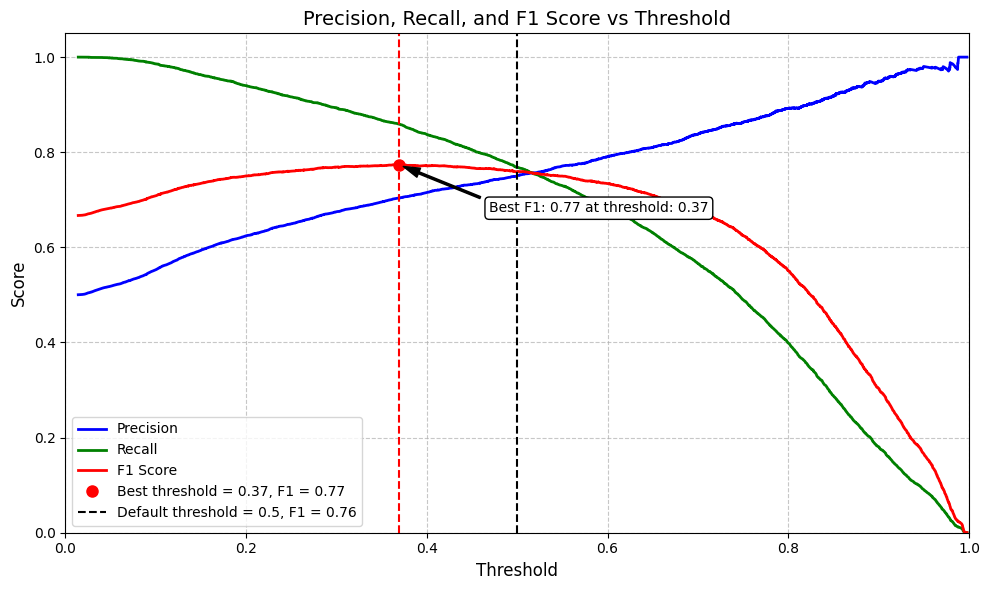

In [149]:
best_threshold, best_f1 = plot_precision_recall_f1_vs_threshold(y_test, preds)